In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

In [2]:
# Set the default figure size
plt.rcParams['figure.figsize'] = (10, 6)
sns.set(color_codes = True)
pd.set_option('display.width', 1200)
pd.set_option('display.max_columns', None)

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yogape/logistics-operations-database")

print("Path to dataset files:", path)
os.listdir(path)

Path to dataset files: C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1


['customers.csv',
 'DATABASE_SCHEMA.txt',
 'delivery_events.csv',
 'drivers.csv',
 'driver_monthly_metrics.csv',
 'facilities.csv',
 'fuel_purchases.csv',
 'loads.csv',
 'maintenance_records.csv',
 'routes.csv',
 'safety_incidents.csv',
 'trailers.csv',
 'trips.csv',
 'trucks.csv',
 'truck_utilization_metrics.csv']

In [4]:
database_schema_path = r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\DATABASE_SCHEMA.txt"
with open(database_schema_path, "r", encoding='utf-8') as file:
    print(file.read())


LOGISTICS DATABASE SCHEMA

1. DRIVERS
   - Primary Key: driver_id
   - Contains: Driver demographics, employment history, license info
   
2. TRUCKS
   - Primary Key: truck_id
   - Contains: Fleet equipment details, acquisition info, status
   
3. TRAILERS
   - Primary Key: trailer_id
   - Contains: Trailer inventory, types, status
   
4. CUSTOMERS
   - Primary Key: customer_id
   - Contains: Customer accounts, contract types, revenue potential
   
5. FACILITIES
   - Primary Key: facility_id
   - Contains: Terminal and warehouse locations, capacity
   
6. ROUTES
   - Primary Key: route_id
   - Contains: Origin-destination pairs, distances, rate structures
   
7. LOADS
   - Primary Key: load_id
   - Foreign Keys: customer_id, route_id
   - Contains: Shipment details, revenue, booking type
   
8. TRIPS
   - Primary Key: trip_id
   - Foreign Keys: load_id, driver_id, truck_id, trailer_id
   - Contains: Actual trip performance, fuel consumption, duration
   
9. FUEL_PURCHASES
   - Primary

In [5]:
customers=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\customers.csv")
print(customers.head())
print(customers.isnull().sum())

  customer_id          customer_name customer_type  credit_terms_days primary_freight_type account_status contract_start_date  annual_revenue_potential
0   CUST00001        Metro Wholesale     Dedicated                 60              General       Inactive          2020-02-20                    985117
1   CUST00002        National Retail      Contract                 30               Retail         Active          2021-06-02                   4936566
2   CUST00003         XYZ Industries      Contract                 30       Consumer Goods         Active          2020-09-04                   3102814
3   CUST00004          American Corp      Contract                 15        Food/Beverage         Active          2020-11-29                   3948027
4   CUST00005  American Distribution          Spot                 45       Consumer Goods         Active          2020-02-04                   3682564
customer_id                 0
customer_name               0
customer_type               

In [6]:
delivery_events=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\delivery_events.csv")
print(delivery_events.head(2))
print(delivery_events.isnull().sum())

      event_id       load_id       trip_id event_type facility_id          scheduled_datetime             actual_datetime  detention_minutes  on_time_flag location_city location_state
0  EVT00000001  LOAD00000001  TRIP00000001     Pickup    FAC00034  2022-01-01 18:00:00.000000  2022-01-01 20:58:55.918185                  0         False       Houston             TX
1  EVT00000002  LOAD00000001  TRIP00000001   Delivery    FAC00046  2022-01-02 23:10:55.918185  2022-01-02 21:30:22.142060                230          True       Detroit             MI
event_id              0
load_id               0
trip_id               0
event_type            0
facility_id           0
scheduled_datetime    0
actual_datetime       0
detention_minutes     0
on_time_flag          0
location_city         0
location_state        0
dtype: int64


In [7]:
drivers=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\drivers.csv")
print(drivers.head(2))
print(drivers.isnull().sum())

  driver_id first_name  last_name   hire_date termination_date license_number license_state date_of_birth home_terminal employment_status cdl_class  years_experience
0  DRV00001   Jennifer  Hernandez  2014-10-31              NaN    DL673510887            WA    1973-11-07        Denver            Active         A                 3
1  DRV00002    William     Martin  2020-10-02              NaN    DL128955006            GA    1976-11-03      Columbus            Active         A                20
driver_id              0
first_name             0
last_name              0
hire_date              0
termination_date     124
license_number         0
license_state          0
date_of_birth          0
home_terminal          0
employment_status      0
cdl_class              0
years_experience       0
dtype: int64


In [8]:
driver_monthly_metrics=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\driver_monthly_metrics.csv")
print(driver_monthly_metrics.head(2))
print(driver_monthly_metrics.isnull().sum())

  driver_id       month  trips_completed  total_miles  total_revenue  average_mpg  total_fuel_gallons  on_time_delivery_rate  average_idle_hours
0  DRV00001  2022-01-01               26        36620       79141.59         6.61              5574.7                  0.385                 8.2
1  DRV00001  2022-02-01                9        13515       27133.87         6.69              2095.1                  0.333                 6.8
driver_id                0
month                    0
trips_completed          0
total_miles              0
total_revenue            0
average_mpg              0
total_fuel_gallons       0
on_time_delivery_rate    0
average_idle_hours       0
dtype: int64


In [9]:
facilities=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\facilities.csv")
print(facilities.head(2))
print(facilities.isnull().sum())

  facility_id                facility_name facility_type         city state  latitude  longitude  dock_doors operating_hours
0    FAC00001  Houston Distribution Center    Cross-Dock      Houston    TX   29.7604   -95.3698         125            24/7
1    FAC00002              Kansas City Hub    Cross-Dock  Kansas City    MO   39.0997   -94.5786          33         7AM-7PM
facility_id        0
facility_name      0
facility_type      0
city               0
state              0
latitude           0
longitude          0
dock_doors         0
operating_hours    0
dtype: int64


In [10]:
fuel_purchases=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\fuel_purchases.csv")
print(fuel_purchases.head(2))
print(fuel_purchases.isnull().sum())

  fuel_purchase_id       trip_id  truck_id driver_id        purchase_date location_city location_state  gallons  price_per_gallon  total_cost fuel_card_number
0     FUEL00000001  TRIP00051284  TRK00045  DRV00102  2023-10-22 05:00:00      Columbus             MN    131.6             3.399      447.31         FC567161
1     FUEL00000002  TRIP00073723  TRK00013       NaN  2024-08-04 08:00:00      New York             AZ    139.9             3.180      444.88         FC717910
fuel_purchase_id       0
trip_id                0
truck_id            3880
driver_id           3988
purchase_date          0
location_city          0
location_state         0
gallons                0
price_per_gallon       0
total_cost             0
fuel_card_number       0
dtype: int64


In [11]:
loads=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\loads.csv")
print(loads.head(2))
print(loads.isnull().sum())

        load_id customer_id  route_id   load_date load_type  weight_lbs  pieces  revenue  fuel_surcharge  accessorial_charges load_status booking_type
0  LOAD00000001   CUST00183  RTE00019  2022-01-01   Dry Van       19178      13  3045.23          406.72                  100   Completed         Spot
1  LOAD00000002   CUST00076  RTE00058  2022-01-01   Dry Van       27761      22  1224.48           98.61                    0   Completed    Dedicated
load_id                0
customer_id            0
route_id               0
load_date              0
load_type              0
weight_lbs             0
pieces                 0
revenue                0
fuel_surcharge         0
accessorial_charges    0
load_status            0
booking_type           0
dtype: int64


In [12]:
maintenance_records=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\maintenance_records.csv")
print(maintenance_records.head(2))
print(maintenance_records.isnull().sum())
print(maintenance_records['maintenance_type'].unique())
print(maintenance_records['service_description'].unique())


  maintenance_id  truck_id maintenance_date maintenance_type  odometer_reading  labor_hours  labor_cost  parts_cost  total_cost facility_location  downtime_hours   service_description
0  MAINT00000001  TRK00085       2022-01-01       Inspection            400255          7.8      781.42       10.41      791.83       Kansas City            22.2  Emergency Inspection
1  MAINT00000002  TRK00041       2022-01-01             Tire            268041          0.9       80.91     3207.16     3288.07           Seattle             8.0        Scheduled Tire
maintenance_id         0
truck_id               0
maintenance_date       0
maintenance_type       0
odometer_reading       0
labor_hours            0
labor_cost             0
parts_cost             0
total_cost             0
facility_location      0
downtime_hours         0
service_description    0
dtype: int64
['Inspection' 'Tire' 'Preventive' 'Repair' 'Transmission' 'Brake' 'Engine']
['Emergency Inspection' 'Scheduled Tire' 'Routine Preventiv

In [13]:
routes=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\routes.csv")
print(routes.head(2))
print(routes.isnull().sum())

   route_id origin_city origin_state destination_city destination_state  typical_distance_miles  base_rate_per_mile  fuel_surcharge_rate  typical_transit_days
0  RTE00001     Atlanta           GA          Chicago                IL                     677                1.70                 0.19                     1
1  RTE00002     Atlanta           GA            Miami                FL                     697                2.08                 0.22                     1
route_id                  0
origin_city               0
origin_state              0
destination_city          0
destination_state         0
typical_distance_miles    0
base_rate_per_mile        0
fuel_surcharge_rate       0
typical_transit_days      0
dtype: int64


In [14]:
trailers=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\trailers.csv")
print(trailers.head(2))
print(trailers.isnull().sum())

  trailer_id  trailer_number  trailer_type  length_feet  model_year                 vin acquisition_date  status current_location
0   TRL00001            4290  Refrigerated           53        2016  1AV889081755621178       2018-05-11  Active      Kansas City
1   TRL00002            8848       Dry Van           53        2018  1BU942062588832828       2018-11-24  Active      Kansas City
trailer_id          0
trailer_number      0
trailer_type        0
length_feet         0
model_year          0
vin                 0
acquisition_date    0
status              0
current_location    0
dtype: int64


In [15]:
trips=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\trips.csv")
print(trips.head(2))
print(trips.isnull().sum())
trips.dtypes

        trip_id       load_id driver_id  truck_id trailer_id dispatch_date  actual_distance_miles  actual_duration_hours  fuel_gallons_used  average_mpg  idle_time_hours trip_status
0  TRIP00000001  LOAD00000001  DRV00117  TRK00035   TRL00167    2022-01-01                   1314                   26.2              183.8         7.15              3.5   Completed
1  TRIP00000002  LOAD00000002  DRV00141  TRK00108   TRL00082    2022-01-01                    515                    8.6               93.6         5.50              8.3   Completed
trip_id                     0
load_id                     0
driver_id                1714
truck_id                 1672
trailer_id               1680
dispatch_date               0
actual_distance_miles       0
actual_duration_hours       0
fuel_gallons_used           0
average_mpg                 0
idle_time_hours             0
trip_status                 0
dtype: int64


trip_id                   object
load_id                   object
driver_id                 object
truck_id                  object
trailer_id                object
dispatch_date             object
actual_distance_miles      int64
actual_duration_hours    float64
fuel_gallons_used        float64
average_mpg              float64
idle_time_hours          float64
trip_status               object
dtype: object

In [16]:
safety_incidents=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\safety_incidents.csv")
safety_incidents = safety_incidents.merge(trips[["trip_id","truck_id"]], on="trip_id", how="left", suffixes = ("","_from_trips"))
safety_incidents["truck_id"] = safety_incidents["truck_id"].fillna(safety_incidents["truck_id_from_trips"])
# safety_incidents.drop(columns=["truck_id_from_trips"],inplace=True)

print(safety_incidents.head(2))
print(safety_incidents.isnull().sum())
safety_incidents['incident_type'].unique()

   incident_id       trip_id  truck_id driver_id        incident_date     incident_type location_city location_state  at_fault_flag  injury_flag  vehicle_damage_cost  cargo_damage_cost  claim_amount  preventable_flag                          description truck_id_from_trips
0  INC00000001  TRIP00036079  TRK00006  DRV00006  2023-04-09 14:00:00  Moving Violation      Columbus             PA           True        False             12629.26               0.00      12629.26              True  Severe incident involving equipment            TRK00006
1  INC00000002  TRIP00032462  TRK00084  DRV00006  2023-02-19 11:00:00  Moving Violation      Columbus             NC          False        False              2700.70           14284.24      16984.94             False    Severe incident involving weather            TRK00084
incident_id            0
trip_id                0
truck_id               1
driver_id              1
incident_date          0
incident_type          0
location_city          0
loc

array(['Moving Violation', 'Customer Complaint', 'Equipment Damage',
       'DOT Violation', 'Accident'], dtype=object)

In [17]:
trucks=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\trucks.csv")
print(trucks.head(2))
print(trucks.isnull().sum())

   truck_id  unit_number       make  model_year                 vin acquisition_date  acquisition_mileage fuel_type  tank_capacity_gallons  status home_terminal
0  TRK00001         3463  Peterbilt        2016  1VV205190335317039       2017-04-27                18814    Diesel                    200  Active         Omaha
1  TRK00002         6461   Kenworth        2015  1NV753749606229960       2018-10-04                26795    Diesel                    150  Active       Seattle
truck_id                 0
unit_number              0
make                     0
model_year               0
vin                      0
acquisition_date         0
acquisition_mileage      0
fuel_type                0
tank_capacity_gallons    0
status                   0
home_terminal            0
dtype: int64


In [18]:
truck_utilization_metrics=pd.read_csv(r"C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1\truck_utilization_metrics.csv")
print(truck_utilization_metrics.head(2))
print(truck_utilization_metrics.isnull().sum())

   truck_id       month  trips_completed  total_miles  total_revenue  average_mpg  maintenance_events  maintenance_cost  downtime_hours  utilization_rate
0  TRK00001  2022-01-01               22        39269       84792.02         6.78                   2           4380.98            63.1             0.710
1  TRK00001  2022-02-01               27        40787       88809.05         6.23                   0              0.00             0.0             0.964
truck_id              0
month                 0
trips_completed       0
total_miles           0
total_revenue         0
average_mpg           0
maintenance_events    0
maintenance_cost      0
downtime_hours        0
utilization_rate      0
dtype: int64


In [19]:
incident_category = safety_incidents.groupby('incident_type')['preventable_flag'].value_counts()
print(incident_category)

incident_type       preventable_flag
Accident            False               21
                    True                14
Customer Complaint  False               21
                    True                13
DOT Violation       False               21
                    True                18
Equipment Damage    False               26
                    True                 9
Moving Violation    False               17
                    True                10
Name: count, dtype: int64


In [20]:
for df, col in [(safety_incidents,'trip_id'), (trips,'trip_id'),(trips,'load_id'),(loads,'load_id')]:
    df[col] = df[col].astype(str)


<Axes: xlabel='year'>

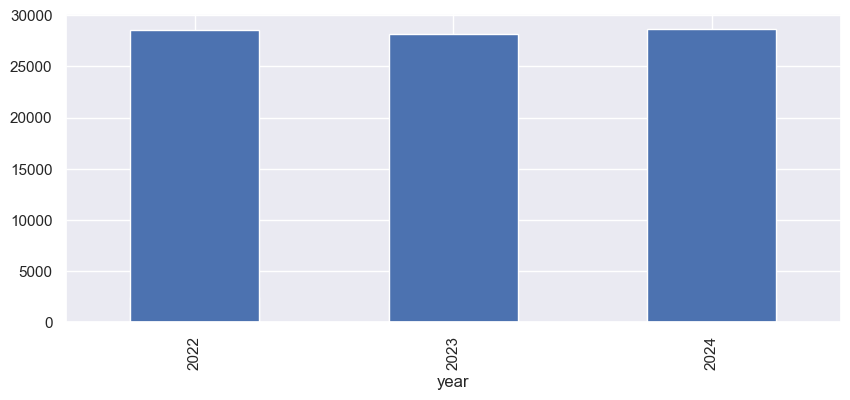

In [21]:
# trip_id -> load_id mapping
trip_to_load = trips[["trip_id", "load_id","dispatch_date"]].drop_duplicates()

# load_id -> route_id mapping
load_to_route = loads[["load_id", "route_id"]].drop_duplicates()

# route_id -> route attributes
route_attributes = routes[[
    "route_id",
    "origin_city",
    "origin_state",
    "destination_city",
    "destination_state",
    "base_rate_per_mile",
    "typical_distance_miles",
    "typical_transit_days"
]].drop_duplicates()

# trip_id -> truck_id
trip_to_truck = trips[["trip_id", "truck_id"]].drop_duplicates()

# truck_id -> truck attributes
truck_attributes = trucks[[
    "truck_id",
    "make",
    "model_year",
    "fuel_type",
    "home_terminal",
    "status",
    "tank_capacity_gallons"
]].drop_duplicates()

# trip_id -> driver_id
trip_to_driver = trips[["trip_id", "driver_id"]].drop_duplicates()

# truck_id -> maintenance metrics (raw mapping)
truck_to_maintenance = maintenance_records[[
    "truck_id",
    "maintenance_id",
    "maintenance_date",
    "total_cost",
    "downtime_hours"
]].drop_duplicates()


# driver_id -> incident metrics
driver_to_incidents = safety_incidents[[
    "driver_id",
    "incident_id",
    "incident_date",
    "claim_amount",
    "cargo_damage_cost",
    "at_fault_flag"
]].drop_duplicates()

# truck_id + month -> utilization metrics
truck_month_to_utilization = truck_utilization_metrics[[
    "truck_id",
    "month",
    "total_miles",
    "total_revenue",
    "trips_completed",
    "utilization_rate",
    "average_mpg"
]].drop_duplicates()

# incidents -> trip_id
incident_to_trip=  safety_incidents[[
    "trip_id",
    "incident_date",
    "truck_id",
    "preventable_flag"
]].drop_duplicates()

safety_incidents['incident_date']=pd.to_datetime(safety_incidents['incident_date'])
safety_incidents['year']=safety_incidents['incident_date'].dt.year
safety_incidents['month']=safety_incidents['incident_date'].dt.month
safety_incidents["month_year"] = safety_incidents["incident_date"].dt.to_period("M")

safety_incidents.head()
incidents_by_month = (
    safety_incidents
    .groupby("month_year")
    .size()
)

incidents_by_month.plot(kind="bar", figsize=(10, 4))
incidents_by_year = (
    safety_incidents
    .groupby("year")
    .size()
)

incidents_by_year.plot(kind="bar", figsize=(10, 4))

trips['dispatch_date']=pd.to_datetime(trips['dispatch_date'])
trips['year']=trips['dispatch_date'].dt.year
trips['month']=trips['dispatch_date'].dt.month
trips['month_year']=trips['dispatch_date'].dt.to_period('M')


trips_by_month = (
    trips
    .groupby("month_year")
    .size()
)
trips_by_year = (
    trips
    .groupby("year")
    .size()
)
trips_by_month.plot(kind="bar", figsize=(10, 4))
trips_by_year.plot(kind="bar", figsize=(10, 4))

    year       incident_type  count
0   2022            Accident      8
1   2022  Customer Complaint     11
2   2022       DOT Violation     15
3   2022    Equipment Damage     14
4   2022    Moving Violation      8
5   2023            Accident      8
6   2023  Customer Complaint     12
7   2023       DOT Violation     11
8   2023    Equipment Damage     10
9   2023    Moving Violation     13
10  2024            Accident     19
11  2024  Customer Complaint     11
12  2024       DOT Violation     13
13  2024    Equipment Damage     11
14  2024    Moving Violation      6
    year       incident_type  preventable_flag  count
0   2022            Accident             False      5
1   2022            Accident              True      3
2   2022  Customer Complaint             False      8
3   2022  Customer Complaint              True      3
4   2022       DOT Violation             False      7
5   2022       DOT Violation              True      8
6   2022    Equipment Damage             False

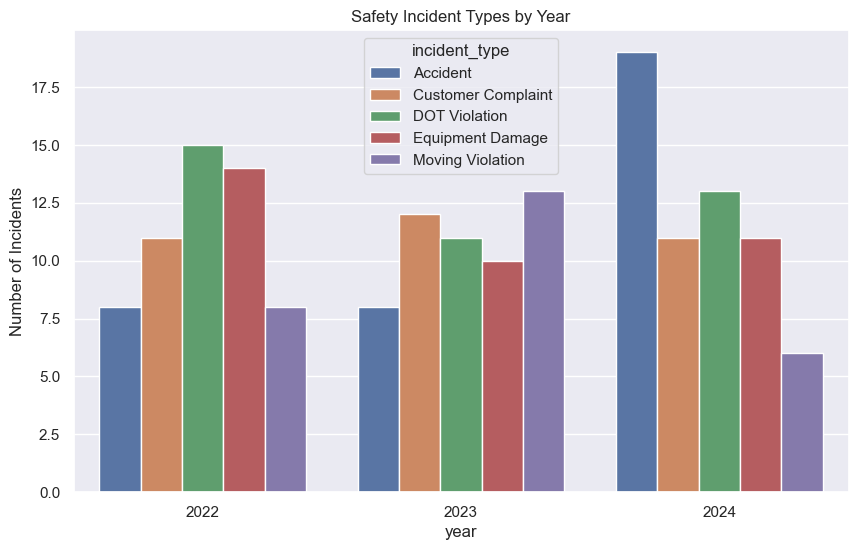

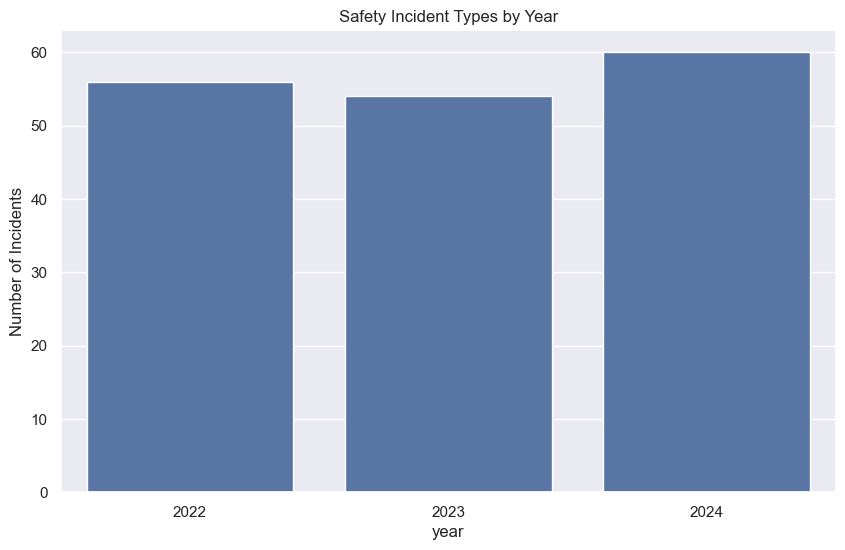

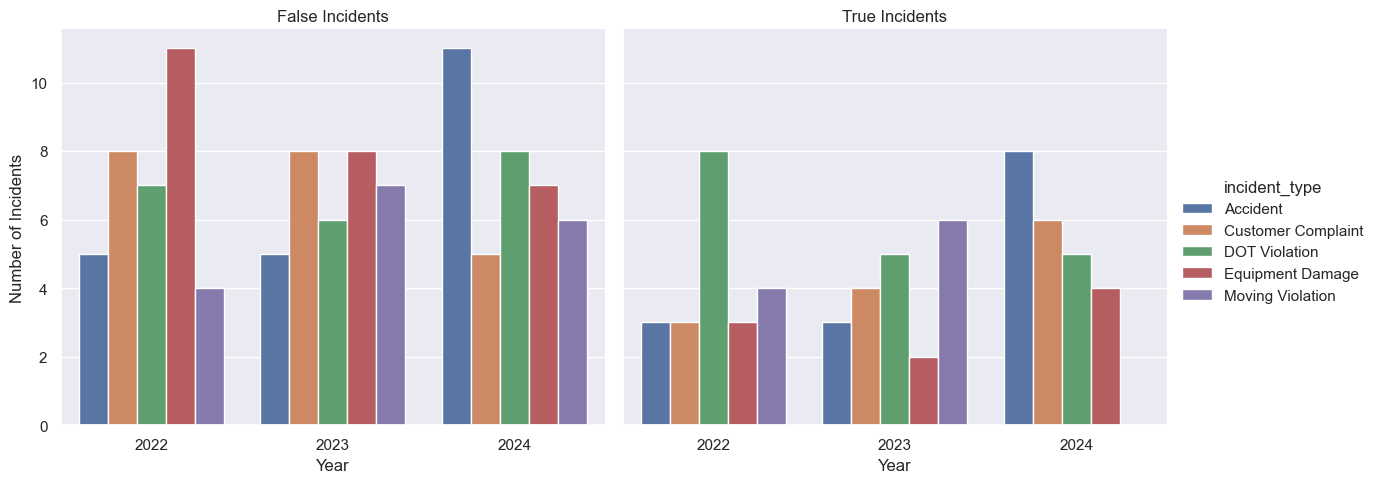

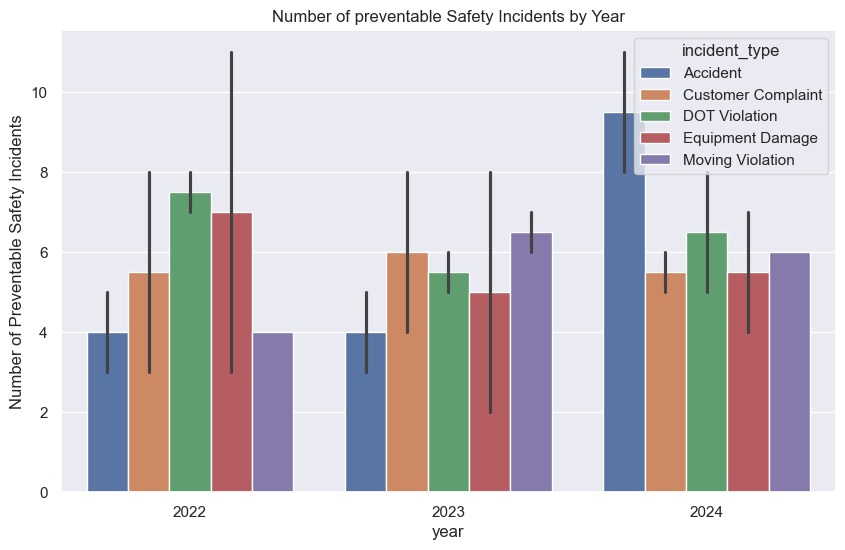

,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description,truck_id_from_trips,month,month_year
year,,,,,,,,,,,,,,,,,,
2022,56,56,56,56,56,56,56,56,56,56,56,56,56,56,56,56,56,56
2023,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54
2024,60,60,59,59,60,60,60,60,60,60,60,60,60,60,60,59,60,60


In [22]:

# Assuming 'df' is your dataframe
# x = the time axis (Years)
# y = the counts
# hue = the category (Incident Type)
incident_type_by_year_count=safety_incidents.groupby(['year','incident_type']).size().reset_index(name='count')
incident_type_by_year_total=safety_incidents.groupby('year').size().reset_index(name='count')
incident_type_by_year_preventable_count=safety_incidents.groupby(['year','incident_type','preventable_flag']).size().reset_index(name='count')
print(incident_type_by_year_count)
print(incident_type_by_year_preventable_count)
plt.figure(figsize=(10, 6))
sns.barplot(data=incident_type_by_year_count, x='year', y='count', hue='incident_type')
plt.title('Safety Incident Types by Year')
plt.ylabel('Number of Incidents')
plt.show()
sns.barplot(data=incident_type_by_year_total, x='year', y='count')
plt.title('Safety Incident Types by Year')
plt.ylabel('Number of Incidents')
plt.show()

# 2. Use catplot to create the side-by-side (facet) view
g = sns.catplot(
    data=incident_type_by_year_preventable_count, 
    kind="bar",
    x="year", 
    y="count", 
    hue="incident_type",
    col="preventable_flag",  # This creates the "side-by-side" effect
    height=5, 
    aspect=1.2
)

# 3. Add titles and labels
g.set_axis_labels("Year", "Number of Incidents")
g.set_titles("{col_name} Incidents") # Uses the value in preventable_flag as the title for each side
plt.show()
sns.barplot(data=incident_type_by_year_preventable_count, x='year', y='count', hue='incident_type')
plt.title('Number of preventable Safety Incidents by Year')
plt.ylabel('Number of Preventable Safety Incidents')
plt.show()
safety_incidents.groupby('year').count()


year
2022    994
2023    993
2024    933
dtype: int64


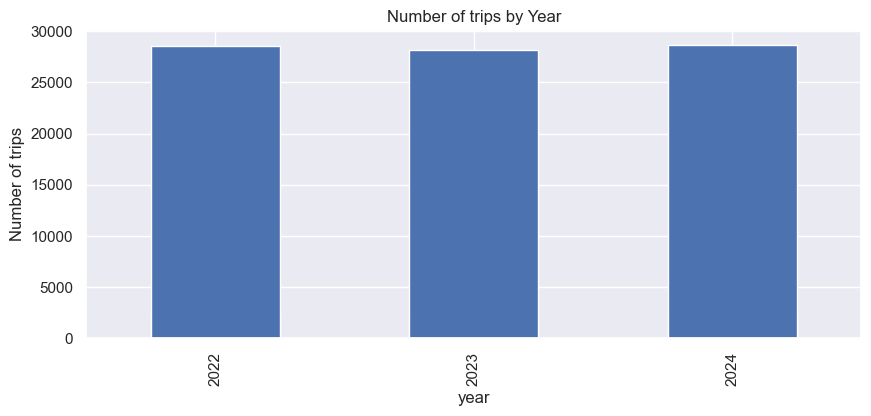

In [23]:
# trip_id -> load_id mapping
trip_to_load = trips[["trip_id", "load_id","dispatch_date"]].drop_duplicates()

# load_id -> route_id mapping
load_to_route = loads[["load_id", "route_id"]].drop_duplicates()

# route_id -> route attributes
route_attributes = routes[[
    "route_id",
    "origin_city",
    "origin_state",
    "destination_city",
    "destination_state",
    "base_rate_per_mile",
    "typical_distance_miles",
    "typical_transit_days"
]].drop_duplicates()

# trip_id -> truck_id
trip_to_truck = trips[["trip_id", "truck_id"]].drop_duplicates()

# truck_id -> truck attributes
truck_attributes = trucks[[
    "truck_id",
    "make",
    "model_year",
    "fuel_type",
    "home_terminal",
    "status",
    "tank_capacity_gallons"
]].drop_duplicates()

# trip_id -> driver_id
trip_to_driver = trips[["trip_id", "driver_id"]].drop_duplicates()

# truck_id -> maintenance metrics (raw mapping)
truck_to_maintenance = maintenance_records[[
    "truck_id",
    "maintenance_id",
    "maintenance_date",
    "total_cost",
    "downtime_hours"
]].drop_duplicates()
maintenance_records["maintenance_date"]=pd.to_datetime(maintenance_records["maintenance_date"])
maintenance_records["year"]=maintenance_records["maintenance_date"].dt.year
maintenance_records["month"]=maintenance_records["maintenance_date"].dt.month
maintenance_records["month_year"]=maintenance_records["maintenance_date"].dt.to_period("M")

maintenance_by_year =maintenance_records.groupby("year").size()
print(maintenance_by_year)
maintenance_by_year.plot(kind="bar",figsize=(10,4))
# driver_id -> incident metrics
driver_to_incidents = safety_incidents[[
    "driver_id",
    "incident_id",
    "incident_date",
    "claim_amount",
    "cargo_damage_cost",
    "at_fault_flag"
]].drop_duplicates()

# truck_id + month -> utilization metrics
truck_month_to_utilization = truck_utilization_metrics[[
    "truck_id",
    "month",
    "total_miles",
    "total_revenue",
    "trips_completed",
    "utilization_rate",
    "average_mpg"
]].drop_duplicates()

# incidents -> trip_id
incident_to_trip=  safety_incidents[[
    "trip_id",
    "incident_date",
    "truck_id",
    "preventable_flag"
]].drop_duplicates()

safety_incidents['incident_date']=pd.to_datetime(safety_incidents['incident_date'])
safety_incidents['year']=safety_incidents['incident_date'].dt.year
safety_incidents['month']=safety_incidents['incident_date'].dt.month
safety_incidents["month_year"] = safety_incidents["incident_date"].dt.to_period("M")


safety_incidents.head()
incidents_by_month = (
    safety_incidents
    .groupby("month_year")
    .size()
)

incidents_by_month.plot(kind="bar", figsize=(10, 4))
incidents_by_year = (
    safety_incidents
    .groupby("year")
    .size()
)

incidents_by_year.plot(kind="bar", figsize=(10, 4))

trips['dispatch_date']=pd.to_datetime(trips['dispatch_date'])
trips['year']=trips['dispatch_date'].dt.year
trips['month']=trips['dispatch_date'].dt.month
trips['month_year']=trips['dispatch_date'].dt.to_period('M')


trips_by_month = (
    trips
    .groupby("month_year")
    .size()
)
trips_by_year = (
    trips
    .groupby("year")
    .size()
)
trips_by_month.plot(kind="bar", figsize=(10, 4))
trips_by_year.plot(kind="bar", figsize=(10, 4))
plt.title('Number of trips by Year')
plt.ylabel('Number of trips')
plt.show()

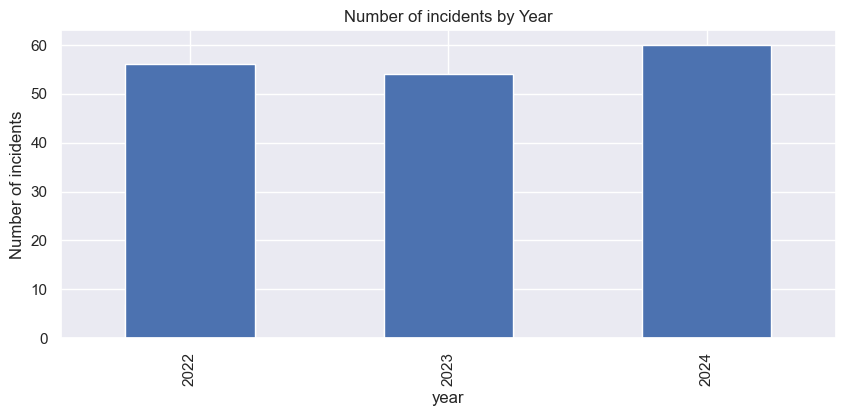

In [24]:
incidents_by_month.plot(kind="bar", figsize=(10, 4))
incidents_by_year = (
    safety_incidents
    .groupby("year")
    .size()
)

incidents_by_year.plot(kind="bar", figsize=(10, 4))
plt.title('Number of incidents by Year')
plt.ylabel('Number of incidents')
plt.show()

year
2022    994
2023    993
2024    933
Name: maintenance_type, dtype: int64


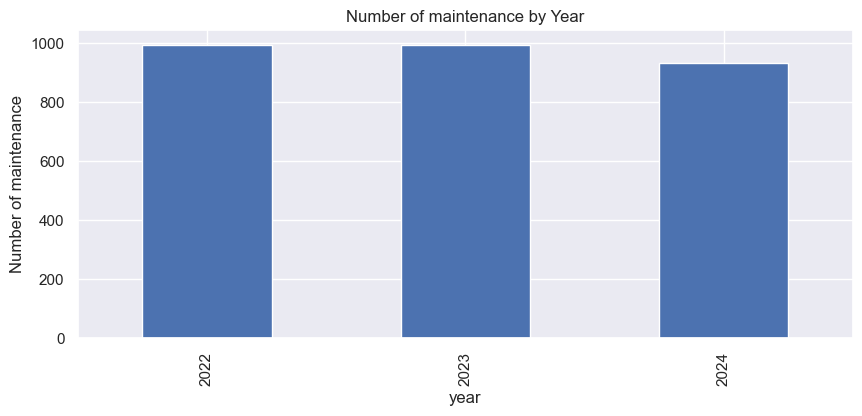

Index(['maintenance_id', 'truck_id', 'maintenance_date', 'maintenance_type', 'odometer_reading', 'labor_hours', 'labor_cost', 'parts_cost', 'total_cost', 'facility_location', 'downtime_hours', 'service_description', 'year', 'month', 'month_year'], dtype='object')

In [25]:
maintenance_by_year =maintenance_records.groupby("year")["maintenance_type"].size()
print(maintenance_by_year)
maintenance_by_year.plot(kind="bar",figsize=(10,4))
plt.title('Number of maintenance by Year')
plt.ylabel('Number of maintenance')
plt.show()
maintenance_records.columns

<Axes: xlabel='year', ylabel='count'>

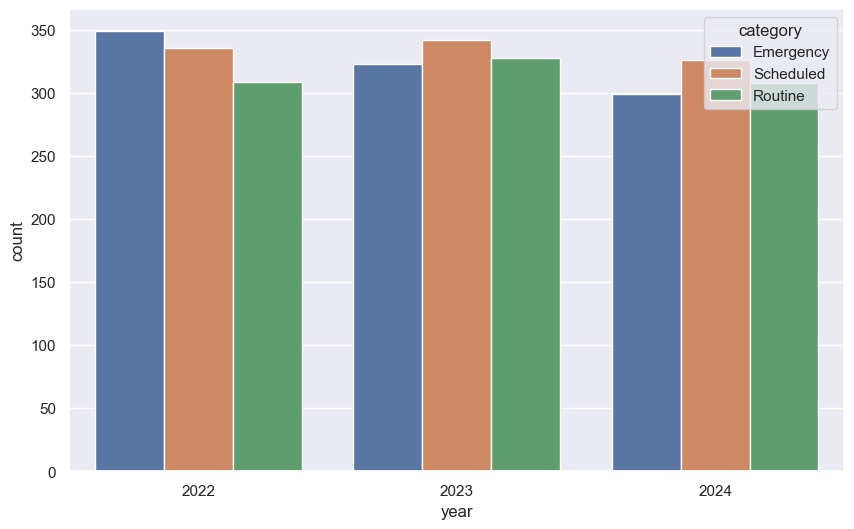

In [26]:
# Create a mapping function
def categorize_service(desc):
    if 'Emergency' in desc:
        return 'Emergency'
    elif 'Scheduled' in desc:
        return 'Scheduled'    
    else:
        return 'Routine'

# Apply to dataframe
maintenance_records['category'] = maintenance_records['service_description'].apply(categorize_service)

# Plot the trend
sns.countplot(data=maintenance_records, x='year', hue='category')

In [27]:
safety_incidents2=safety_incidents.merge(trips, on='trip_id', how='left').merge(loads, on='load_id', how='left').merge(routes, on='route_id',how='left')
total_incidents = safety_incidents2.groupby('route_id').agg(total_incidents=('incident_id','count'))
preventable_incidents = safety_incidents2.loc[safety_incidents2['preventable_flag']==True].groupby('route_id').agg(preventable_incidents=('incident_id','count'))
safety_route_rating = (
    total_incidents
    .join(preventable_incidents, how="left")
    .fillna(0)
)


In [28]:
safety_route_rating["preventable_rate"] = (
    safety_route_rating['preventable_incidents'] /safety_route_rating['total_incidents']
)
print(safety_route_rating.head())

          total_incidents  preventable_incidents  preventable_rate
route_id                                                          
RTE00001                4                    2.0               0.5
RTE00002                2                    2.0               1.0
RTE00003                4                    2.0               0.5
RTE00004                2                    0.0               0.0
RTE00005                4                    4.0               1.0


Axes(0.125,0.11;0.775x0.77)


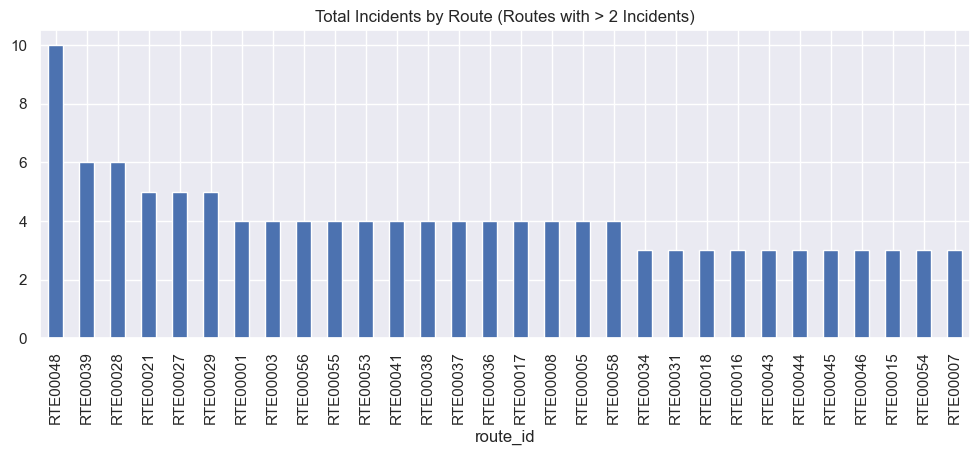

In [29]:
filtered = safety_route_rating[safety_route_rating["total_incidents"] > 2]

print(filtered.sort_values("total_incidents", ascending=False)["total_incidents"].plot(
    kind="bar",
    figsize=(12, 4),
    title="Total Incidents by Route (Routes with > 2 Incidents)"
))


In [30]:
# Get cleaned route IDs
routes_filtered = (
    filtered.index
            .astype(str)
            .str.strip()
            .tolist()
)

print(routes_filtered)
incidents_subset = safety_incidents2[
    safety_incidents2['route_id'].isin(routes_filtered)
].copy()
incidents_subset.head()
incidents_subset['year']=pd.to_datetime(incidents_subset['incident_date']).dt.year
incidents_subset.loc[incidents_subset['route_id']=='RTE00048'].groupby(['year','route_id'])['route_id'].count()
incidents_subset[
    incidents_subset['route_id'].isin(['RTE00048', 'RTE00039', 'RTE00028'])
].groupby(['year', 'route_id'])['incident_id'].nunique()

['RTE00001', 'RTE00003', 'RTE00005', 'RTE00007', 'RTE00008', 'RTE00015', 'RTE00016', 'RTE00017', 'RTE00018', 'RTE00021', 'RTE00027', 'RTE00028', 'RTE00029', 'RTE00031', 'RTE00034', 'RTE00036', 'RTE00037', 'RTE00038', 'RTE00039', 'RTE00041', 'RTE00043', 'RTE00044', 'RTE00045', 'RTE00046', 'RTE00048', 'RTE00053', 'RTE00054', 'RTE00055', 'RTE00056', 'RTE00058']


year  route_id
2022  RTE00028    4
      RTE00039    2
      RTE00048    6
2023  RTE00039    2
      RTE00048    1
2024  RTE00028    2
      RTE00039    2
      RTE00048    3
Name: incident_id, dtype: int64

In [31]:
routes.head()
# Filter rows where route_id is in your list
filtered_routes = routes[routes['route_id'].isin(routes_filtered)]

# Select what you want
filtered_routes[['route_id', 'typical_distance_miles']]
avg_distance = filtered_routes['typical_distance_miles'].mean()
print(avg_distance)
print(filtered_routes.loc[
    filtered_routes['route_id'].isin(['RTE00048', 'RTE00039', 'RTE00028']),
    ['route_id', 'typical_distance_miles']
])

filtered_loads=filtered_routes.merge(loads, on ='route_id', how='left')
filtered_loads['year'] = pd.to_datetime(
    filtered_loads['load_date'],  # or whatever your date column is
    errors='coerce'
).dt.year
filtered_loads.loc[
    filtered_loads['route_id'].isin(['RTE00048', 'RTE00039', 'RTE00028'])
].groupby(['route_id','year'])['weight_lbs'].mean()
# filtered_loads.groupby(['year','route_id'])['weight_lbs'].mean()

1477.0666666666666
    route_id  typical_distance_miles
27  RTE00028                    2172
38  RTE00039                    1044
47  RTE00048                    2332


route_id  year
RTE00028  2022    28167.906130
          2023    27921.426587
          2024    27375.794715
RTE00039  2022    28353.840551
          2023    26258.175258
          2024    27793.827740
RTE00048  2022    28014.193613
          2023    27219.313840
          2024    26557.129159
Name: weight_lbs, dtype: float64

In [32]:
trips['trip_id'].unique()

array(['TRIP00000001', 'TRIP00000002', 'TRIP00000003', ...,
       'TRIP00085408', 'TRIP00085409', 'TRIP00085410'],
      shape=(85410,), dtype=object)

In [33]:
# # trip_id -> load_id mapping
# trip_to_load = trips[["trip_id", "load_id"]].drop_duplicates()

# # load_id -> route_id mapping
# load_to_route = loads[["load_id", "route_id"]].drop_duplicates()

# route_id -> trip_id mapping
route_to_trip = routes[["route_id", "typical_distance_miles"]].drop_duplicates()


trips2=trips.merge(load_to_route,how='left', on='load_id')
print(trips2)
trips2=trips2.merge(route_to_trip,how='left', on='route_id')
print(trips2)


            trip_id       load_id driver_id  truck_id trailer_id dispatch_date  actual_distance_miles  actual_duration_hours  fuel_gallons_used  average_mpg  idle_time_hours trip_status  year  month month_year  route_id
0      TRIP00000001  LOAD00000001  DRV00117  TRK00035   TRL00167    2022-01-01                   1314                   26.2              183.8         7.15              3.5   Completed  2022      1    2022-01  RTE00019
1      TRIP00000002  LOAD00000002  DRV00141  TRK00108   TRL00082    2022-01-01                    515                    8.6               93.6         5.50              8.3   Completed  2022      1    2022-01  RTE00058
2      TRIP00000003  LOAD00000003  DRV00032  TRK00031   TRL00138    2022-01-01                   2509                   45.0              339.1         7.40             12.0   Completed  2022      1    2022-01  RTE00048
3      TRIP00000004  LOAD00000004  DRV00083  TRK00105   TRL00018    2022-01-01                    717                   

Is RTE00048's incident rate higher than the network average?
Normalize by exposure (trips, miles, hours)


Poisson rate test 
A Poisson rate test is a statistical hypothesis test used when you’re dealing with count data (events) that happen over time, area, or exposure, and you want to test whether the event rate is what you expect—or whether two rates differ.

Outcome = count of incidents

Exposure = trips or miles

Events are relatively rare

Null hypothesis (H₀): 
Route RTE00048 has the same incident rate per trip as the network
Alternative hypothesis (H₁):
Route RTE00048 has a higher incident rate per trip

In [34]:
from statsmodels.stats.rates import test_poisson_2indep

# Route RTE00048
incidents_RTE00048 = safety_incidents2.loc[safety_incidents2['route_id']=="RTE00048",'incident_id'].nunique()
trips_RTE00048 = trips2.loc[trips2['route_id']=="RTE00048",'trip_id'].nunique()

# All other routes combined
incidents_all = safety_incidents2['incident_id'].nunique()
incidents_other = incidents_all - incidents_RTE00048
trips_all = trips2['trip_id'].nunique()
trips_other = trips_all - trips_RTE00048

result = test_poisson_2indep(
    count1=incidents_RTE00048,
    exposure1=trips_RTE00048,
    count2=incidents_all,
    exposure2=trips_all,
    alternative="larger"
)
rate_ratio = result[0]
p_value = result[1]
print("Rate ratio:", rate_ratio)
print("p-value:", p_value)


Rate ratio: 3.8849186631282198
p-value: 5.118207642329016e-05


In [ ]:
Exposure = total miles driven

Is this route inherently risky?


Null hypothesis (H₀)

The incident rate per mile on this route is the same as (or lower than) average

Alternative hypothesis (H₁)

The incident rate per mile on this route is higher than average


In [35]:
from statsmodels.stats.rates import test_poisson_2indep

# Route RTE00048
incidents_RTE00048 = safety_incidents2.loc[safety_incidents2['route_id']=="RTE00048",'incident_id'].nunique()
miles_RTE00048 = trips2.loc[trips2['route_id']=="RTE00048",'typical_distance_miles'].sum()

# All other routes combined
incidents_all = safety_incidents2['incident_id'].nunique()
incidents_other = incidents_all - incidents_RTE00048
miles_all = trips2['typical_distance_miles'].sum()
miles_all_other = miles_all - miles_RTE00048
result = test_poisson_2indep(
    count1=incidents_RTE00048,
    exposure1=miles_RTE00048,
    count2=incidents_other,
    exposure2=miles_all_other,
    alternative="larger"
)
rate_ratio = result[0]
p_value = result[1]
print("Rate ratio:", rate_ratio)
print("p-value:", p_value)


Rate ratio: 2.2062926236295426
p-value: 0.013681758765184895
